In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import joblib
import os

I0000 00:00:1789640105.984736  309047 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1789640105.988575  309047 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1789640106.279314  309047 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1789640107.760109  309047 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

In [6]:
%pip install tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 3.0 MB/s  0:02:17 eta 0:00:010:00:05
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 2.3 MB/s  0:00:03 eta 0:00:010:01:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 4.2 MB/s  0:00:015.1 MB/s eta 0:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 3.3 MB/s  0:00:00a 0:00:01m eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 3.4 MB/s  0:00:07 eta 0:00:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17/17 [tensorflow]37m━━ 16/17 [tensorflow]a]
Note: you may need to restart the kernel to use updated packages.


In [2]:
X_train = pd.read_csv("processed/X_train_processed.csv")
X_test = pd.read_csv("processed/X_test_processed.csv")

y_train = pd.read_csv("processed/y_train.csv").squeeze()
y_test = pd.read_csv("processed/y_test.csv").squeeze()

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (5634, 65)
X_test : (1409, 65)
y_train: (5634,)
y_test : (1409,)


In [4]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=6,
        class_weight="balanced",
        random_state=42
    ),

    "KNN": KNeighborsClassifier(
        n_neighbors=7
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=150,
        max_depth=10,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=150,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )
}

In [5]:
results = []
trained_models = {}

for name, model in models.items():

    print(f"Training {name}...")

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_prob)
    pr_auc = average_precision_score(y_test, y_prob)

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "ROC-AUC": roc_auc,
        "PR-AUC": pr_auc
    })

    trained_models[name] = model

results_df = pd.DataFrame(results)

results_df

Training Logistic Regression...
Training Decision Tree...
Training KNN...
Training Random Forest...
Training Gradient Boosting...


,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Logistic Regression,0.748048,0.516295,0.804813,0.629049,0.847157,0.659388
1,Decision Tree,0.739532,0.505902,0.802139,0.620476,0.825699,0.613713
2,KNN,0.765791,0.561798,0.534759,0.547945,0.798704,0.540624
3,Random Forest,0.772889,0.555785,0.719251,0.627040,0.843199,0.654105
4,Gradient Boosting,0.806246,0.681004,0.508021,0.581930,0.845271,0.661632


In [6]:
results_df.sort_values(
    by="F1",
    ascending=False
).reset_index(drop=True)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Logistic Regression,0.748048,0.516295,0.804813,0.629049,0.847157,0.659388
1,Random Forest,0.772889,0.555785,0.719251,0.627040,0.843199,0.654105
2,Decision Tree,0.739532,0.505902,0.802139,0.620476,0.825699,0.613713
3,Gradient Boosting,0.806246,0.681004,0.508021,0.581930,0.845271,0.661632
4,KNN,0.765791,0.561798,0.534759,0.547945,0.798704,0.540624


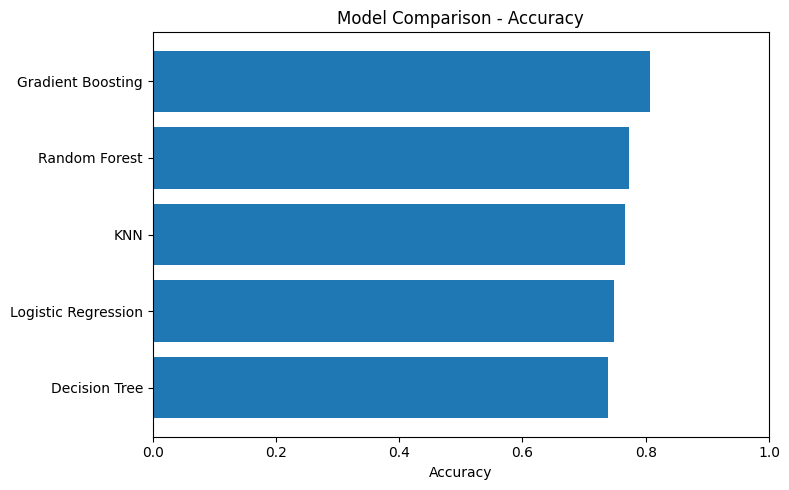

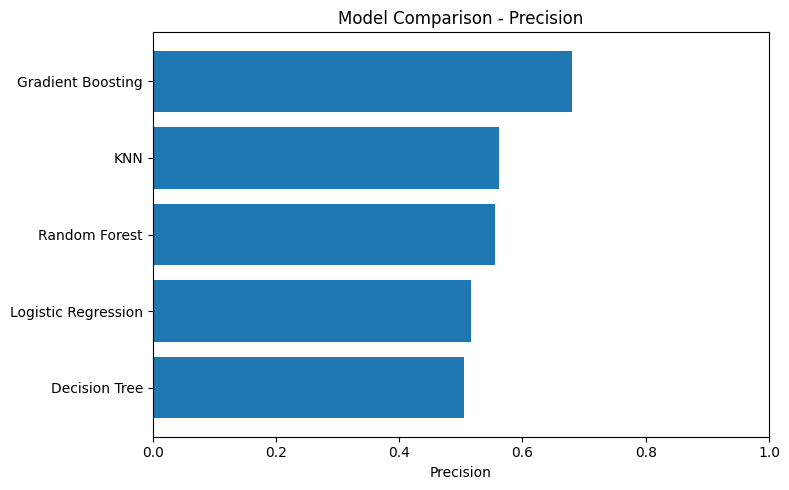

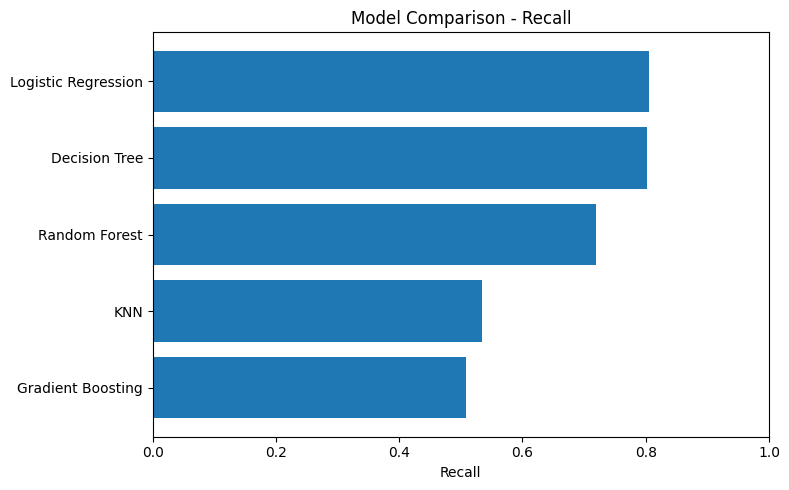

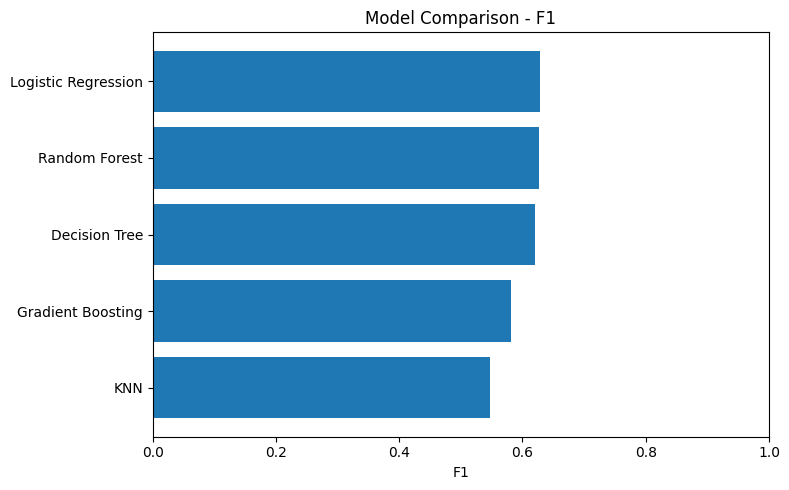

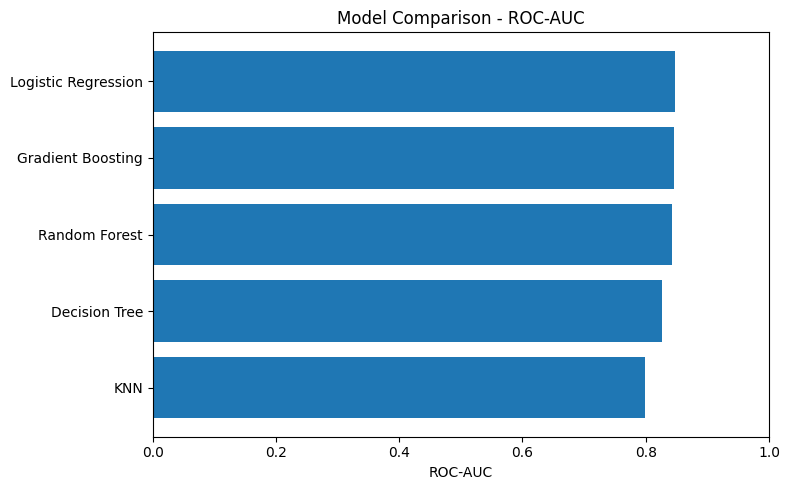

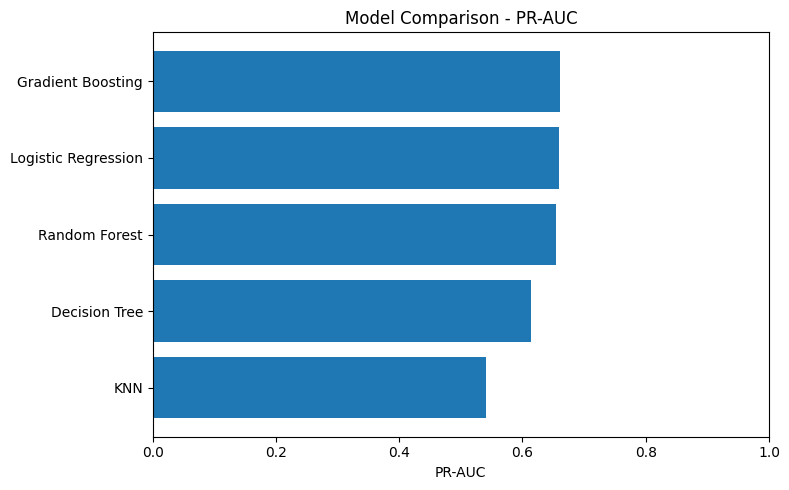

In [7]:
metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "ROC-AUC",
    "PR-AUC"
]

for metric in metrics:

    plt.figure(figsize=(8, 5))

    sorted_data = results_df.sort_values(metric)

    plt.barh(
        sorted_data["Model"],
        sorted_data[metric]
    )

    plt.xlabel(metric)
    plt.title(f"Model Comparison - {metric}")
    plt.xlim(0, 1)
    plt.tight_layout()
    plt.show()

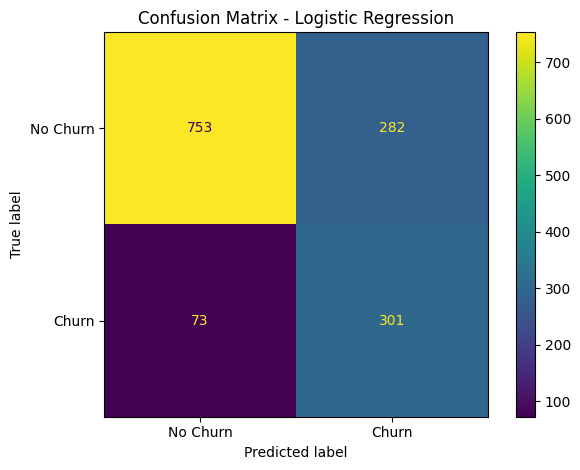

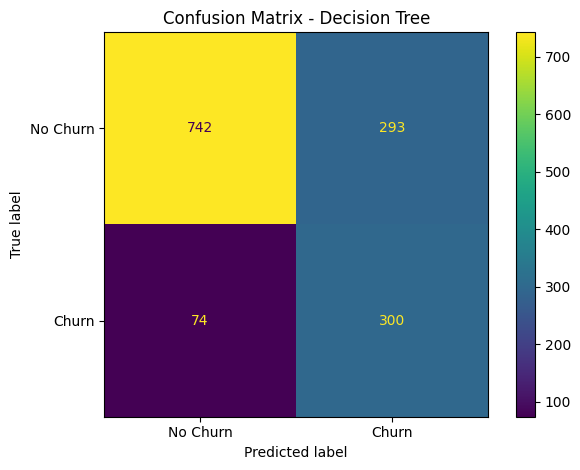

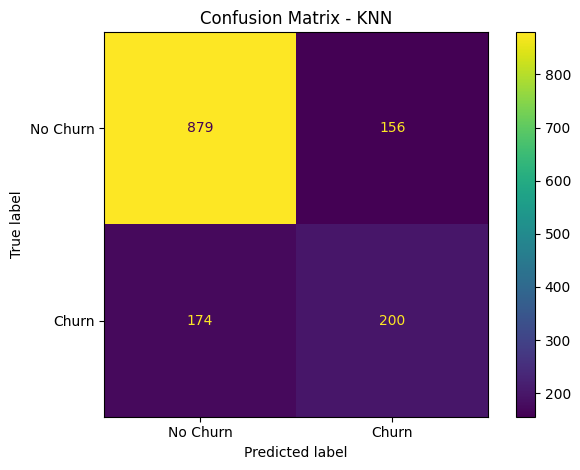

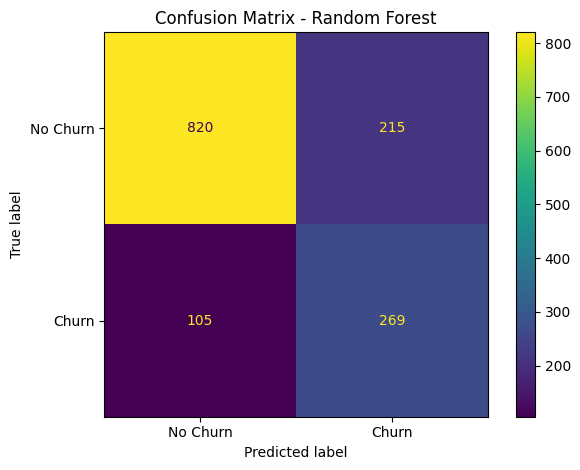

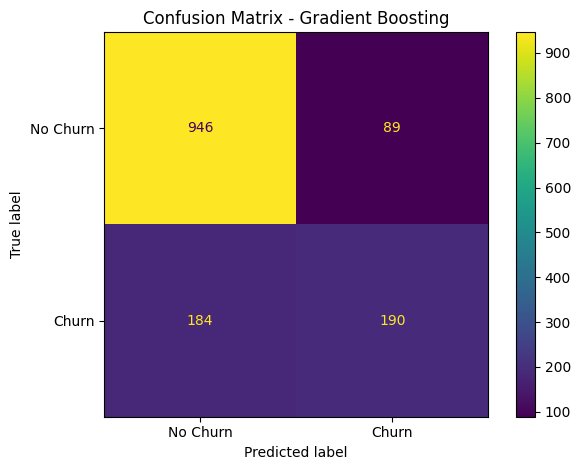

In [8]:
for name, model in trained_models.items():

    y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["No Churn", "Churn"]
    )

    disp.plot()
    plt.title(f"Confusion Matrix - {name}")
    plt.tight_layout()
    plt.show()

In [10]:
pip install xgboost


   ---------------------------------------- 0.0/124.9 MB ? eta -:--:--
   ---------------------------------------- 0.5/124.9 MB 8.5 MB/s eta 0:00:15
    --------------------------------------- 1.8/124.9 MB 12.6 MB/s eta 0:00:10
   - -------------------------------------- 6.0/124.9 MB 11.9 MB/s eta 0:00:10
   --- ------------------------------------ 11.0/124.9 MB 15.6 MB/s eta 0:00:08
   ---- ----------------------------------- 12.6/124.9 MB 14.3 MB/s eta 0:00:08
   ----- ---------------------------------- 17.3/124.9 MB 15.1 MB/s eta 0:00:08
   ------ --------------------------------- 21.8/124.9 MB 16.0 MB/s eta 0:00:07
   --------- ------------------------------ 28.3/124.9 MB 18.0 MB/s eta 0:00:06
   ---------- ----------------------------- 32.2/124.9 MB 18.3 MB/s eta 0:00:06
   ---------- ----------------------------- 33.8/124.9 MB 17.3 MB/s eta 0:00:06
   ----------- ---------------------------- 37.2/124.9 MB 16.8 MB/s eta 0:00:06
   ------------ --------------------------- 39.8/124.

In [11]:
from xgboost import XGBClassifier

In [12]:
xgb_model = XGBClassifier(
    n_estimators=150,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

In [13]:
print("Training XGBoost...")

xgb_model.fit(X_train, y_train)

Training XGBoost...


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=150,
              n_jobs=-1, num_parallel_tree=None, random_state=42, ...)

In [14]:
xgb_pred = xgb_model.predict(X_test)
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

xgb_results = {
    "Model": "XGBoost",
    "Accuracy": accuracy_score(y_test, xgb_pred),
    "Precision": precision_score(y_test, xgb_pred, zero_division=0),
    "Recall": recall_score(y_test, xgb_pred, zero_division=0),
    "F1": f1_score(y_test, xgb_pred, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, xgb_prob),
    "PR-AUC": average_precision_score(y_test, xgb_prob)
}

xgb_results

{'Model': 'XGBoost',
 'Accuracy': 0.8048261178140526,
 'Precision': 0.6701030927835051,
 'Recall': 0.5213903743315508,
 'F1': 0.5864661654135338,
 'ROC-AUC': 0.8461378490790256,
 'PR-AUC': 0.6552618477650514}

In [15]:
results_df = pd.concat(
    [
        results_df,
        pd.DataFrame([xgb_results])
    ],
    ignore_index=True
)

results_df.sort_values(
    by="F1",
    ascending=False
).reset_index(drop=True)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Logistic Regression,0.748048,0.516295,0.804813,0.629049,0.847157,0.659388
1,Random Forest,0.772889,0.555785,0.719251,0.627040,0.843199,0.654105
2,Decision Tree,0.739532,0.505902,0.802139,0.620476,0.825699,0.613713
3,XGBoost,0.804826,0.670103,0.521390,0.586466,0.846138,0.655262
4,Gradient Boosting,0.806246,0.681004,0.508021,0.581930,0.845271,0.661632
5,KNN,0.765791,0.561798,0.534759,0.547945,0.798704,0.540624


In [17]:
os.makedirs("../models", exist_ok=True)

results_df.to_csv(
    "processed/model_comparison.csv",
    index=False
)

print("Model comparison saved.")

Model comparison saved.


In [18]:
best_model_name = results_df.loc[
    results_df["F1"].idxmax(),
    "Model"
]

print("Best model based on F1:", best_model_name)

Best model based on F1: Logistic Regression


In [19]:
if best_model_name == "XGBoost":
    best_model = xgb_model
else:
    best_model = trained_models[best_model_name]

print(best_model)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)


In [20]:
joblib.dump(
    best_model,
    "../models/best_churn_model.pkl"
)

print("Best churn model saved.")

Best churn model saved.


In [21]:
joblib.dump(
    xgb_model,
    "../models/xgboost_churn_model.pkl"
)

print("XGBoost model saved.")

XGBoost model saved.


In [22]:
results_df.sort_values(
    by=["F1", "ROC-AUC"],
    ascending=False
).reset_index(drop=True)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Logistic Regression,0.748048,0.516295,0.804813,0.629049,0.847157,0.659388
1,Random Forest,0.772889,0.555785,0.719251,0.627040,0.843199,0.654105
2,Decision Tree,0.739532,0.505902,0.802139,0.620476,0.825699,0.613713
3,XGBoost,0.804826,0.670103,0.521390,0.586466,0.846138,0.655262
4,Gradient Boosting,0.806246,0.681004,0.508021,0.581930,0.845271,0.661632
5,KNN,0.765791,0.561798,0.534759,0.547945,0.798704,0.540624


In [3]:
X_train_np = X_train.astype("float32").values
X_test_np = X_test.astype("float32").values

y_train_np = y_train.astype("float32")
y_test_np = y_test.astype("float32")

print("Training data prepared.")

Training data prepared.


In [4]:
input_dim = X_train_np.shape[1]

ann_model = Sequential([
    Dense(64, activation="relu", input_shape=(input_dim,)),
    Dropout(0.30),

    Dense(32, activation="relu"),
    Dropout(0.30),

    Dense(1, activation="sigmoid")
])

ann_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

ann_model.summary()

/home/aximsoft/nltk-env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1789640120.032190  309047 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,337 (24.75 KB)

 Trainable params: 6,337 (24.75 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
import time
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

start_time = time.perf_counter()

history = ann_model.fit(
    X_train_np,
    y_train_np,
    validation_split=0.20,
    epochs=30,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

ann_training_time = time.perf_counter() - start_time

print(
    "ANN training time:",
    round(ann_training_time, 3),
    "seconds"
)

Epoch 1/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7413 - loss: 0.5035 - val_accuracy: 0.7879 - val_loss: 0.4406
Epoch 2/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7917 - loss: 0.4417 - val_accuracy: 0.7870 - val_loss: 0.4352
Epoch 3/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8008 - loss: 0.4267 - val_accuracy: 0.7950 - val_loss: 0.4327
Epoch 4/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8030 - loss: 0.4227 - val_accuracy: 0.7888 - val_loss: 0.4362
Epoch 5/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8090 - loss: 0.4193 - val_accuracy: 0.7933 - val_loss: 0.4315
Epoch 6/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8085 - loss: 0.4166 - val_accuracy: 0.7941 - val_loss: 0.4334
Epoch 7/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8087 - loss: 0.4145 - val_accuracy: 0.7959 - val_loss: 0.4316
Epoch 8/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8101 - loss: 0.4107 - val_accuracy: 0.

In [8]:
start_time = time.perf_counter()

ann_probabilities = ann_model.predict(
    X_test_np,
    verbose=0
).ravel()

ann_inference_time = time.perf_counter() - start_time

ann_predictions = (
    ann_probabilities >= 0.50
).astype(int)

print(
    "ANN inference time:",
    round(ann_inference_time, 6),
    "seconds"
)

ANN inference time: 0.291304 seconds


In [9]:
ann_accuracy = accuracy_score(
    y_test_np,
    ann_predictions
)

ann_precision = precision_score(
    y_test_np,
    ann_predictions,
    zero_division=0
)

ann_recall = recall_score(
    y_test_np,
    ann_predictions,
    zero_division=0
)

ann_f1 = f1_score(
    y_test_np,
    ann_predictions,
    zero_division=0
)

ann_roc_auc = roc_auc_score(
    y_test_np,
    ann_probabilities
)

ann_results = {
    "Model": "Small ANN",
    "Accuracy": ann_accuracy,
    "Precision": ann_precision,
    "Recall": ann_recall,
    "F1": ann_f1,
    "ROC-AUC": ann_roc_auc,
    "Training Time": ann_training_time,
    "Inference Time": ann_inference_time
}

ann_results_df = pd.DataFrame([ann_results])

ann_results_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,Training Time,Inference Time
0,Small ANN,0.799148,0.663082,0.494652,0.566616,0.843512,7.963127,0.291304


In [10]:
ann_cm = confusion_matrix(
    y_test_np,
    ann_predictions
)

print("ANN Confusion Matrix:")
print(ann_cm)

ANN Confusion Matrix:
[[941  94]
 [189 185]]


In [18]:
import os
ml_results_path = "processed/model_comparison.csv"

ml_results_df = pd.read_csv(
        ml_results_path
    )

display(ml_results_df)



,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Logistic Regression,0.748048,0.516295,0.804813,0.629049,0.847157,0.659388
1,Decision Tree,0.739532,0.505902,0.802139,0.620476,0.825699,0.613713
2,KNN,0.765791,0.561798,0.534759,0.547945,0.798704,0.540624
3,Random Forest,0.772889,0.555785,0.719251,0.627040,0.843199,0.654105
4,Gradient Boosting,0.806246,0.681004,0.508021,0.581930,0.845271,0.661632
5,XGBoost,0.804826,0.670103,0.521390,0.586466,0.846138,0.655262


In [19]:
comparison_columns = [
    "Model",
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "ROC-AUC"
]

if os.path.exists(ml_results_path):

    comparison_df = pd.concat(
        [
            ml_results_df[comparison_columns],
            ann_results_df[comparison_columns]
        ],
        ignore_index=True
    )

else:

    comparison_df = ann_results_df[
        comparison_columns
    ]

comparison_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.748048,0.516295,0.804813,0.629049,0.847157
1,Decision Tree,0.739532,0.505902,0.802139,0.620476,0.825699
2,KNN,0.765791,0.561798,0.534759,0.547945,0.798704
3,Random Forest,0.772889,0.555785,0.719251,0.627040,0.843199
4,Gradient Boosting,0.806246,0.681004,0.508021,0.581930,0.845271
5,XGBoost,0.804826,0.670103,0.521390,0.586466,0.846138
6,Small ANN,0.799148,0.663082,0.494652,0.566616,0.843512


In [20]:
ann_results_df.to_csv(
    "../data/processed/ann_results.csv",
    index=False
)

comparison_df.to_csv(
    "../data/processed/ml_ann_comparison.csv",
    index=False
)

print("ANN evaluation results saved.")

ANN evaluation results saved.


In [23]:

print("\nANN Metrics:")
print("Accuracy :", round(ann_accuracy, 4))
print("Precision:", round(ann_precision, 4))
print("Recall   :", round(ann_recall, 4))
print("F1       :", round(ann_f1, 4))
print("ROC-AUC  :", round(ann_roc_auc, 4))

print("\nTraining Time:",
      round(ann_training_time, 3),
      "seconds")

print("Inference Time:",
      round(ann_inference_time, 6),
      "seconds")





ANN Metrics:
Accuracy : 0.7991
Precision: 0.6631
Recall   : 0.4947
F1       : 0.5666
ROC-AUC  : 0.8435

Training Time: 7.963 seconds
Inference Time: 0.291304 seconds
